# Connect-4 Lookahead Depth Comparator (Fast LA vs Kaggle bbLA)

This notebook compares **Connect4Lookahead** actions across depths on a fixed board position,
and  compares to **Kaggle bitboard agent** (`N_step_lookahead_bitboard`).

- Paste a board into **Cell 3** (either a `6x7` numpy array or Kaggle flat list).
- Tweak the knobs in **Cell 2** (depths, mark-to-play, LA weights/knobs).
- Re-run **Cell 5+** to generate a table + plots + before/after boards.


In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from tabulate import tabulate

from C4.fast_connect4_lookahead import Connect4Lookahead
from Kaggle.N_step_lookahead_bitboard import N_step_lookahead_bitboard
from C4.game_analysis_helpers import (
    draw_board,
    apply_move,
    legal_cols,
    win_cols,
    board_list_to_np,
    find_board_in_pair,
    show_two_boards,
    opp_mark,
    root_bias_components,
    child_search_value,
)

print("Imports OK.")


Imports OK.


In [2]:
# --- Main knobs (edit) ---

# Which depths to evaluate for Connect4Lookahead
#DEPTHS = list(range(1, 16, 2))   # 1,3,5,7,9,11
DEPTHS = list(range(1, 16, 1))   # 1,3,5,7,9,11

# Show before/after boards for these depths (keep small)
SHOW_BOARDS_FOR = [3, 5, 7, 8, 9, 11, 13]

# Optionally compute full per-column score vectors (can be slow for many depths)
COMPUTE_ACTION_SCORES = True

# --- Lookahead weights/knobs (easy to tweak) ---
# (defaults from the pasted class header)
LA_WEIGHTS = {2: 1.0, 3: 1000.0, 4: 100000.0}

LA_KNOBS = dict(
    DEFENSIVE=1.5, 
    FLOATING_NEAR=0.50, #0.25
    FLOATING_FAR=0.075,
    CENTER_BONUS=7.0,
    PARITY_BONUS=1.0,
    VERT_MUL=0.7,
    VERT_3_READY_BONUS=0.0,
    TEMPO_W=2.0,
    PARITY_MOVE_W=0.3,
    PARITY_UNLOCK_W=0.2,
    THREATSPACE_W=1.0,
)

OPENING_RANDOM = True


In [3]:
# --- Instantiate LA + apply knobs ---
la = Connect4Lookahead(weights=LA_WEIGHTS)

for k, v in LA_KNOBS.items():
    setattr(la, k, v)

la.OPENING_RANDOM = bool(OPENING_RANDOM)

# IMPORTANT:
# Some helper functions expect a global variable named `la`.
# We keep it exactly as `la` here on purpose.
print("LA ready. Knobs:", {k: getattr(la, k) for k in LA_KNOBS.keys()})


LA ready. Knobs: {'DEFENSIVE': 1.5, 'FLOATING_NEAR': 0.5, 'FLOATING_FAR': 0.075, 'CENTER_BONUS': 7.0, 'PARITY_BONUS': 1.0, 'VERT_MUL': 0.7, 'VERT_3_READY_BONUS': 0.0, 'TEMPO_W': 2.0, 'PARITY_MOVE_W': 0.3, 'PARITY_UNLOCK_W': 0.2, 'THREATSPACE_W': 1.0}


## Board

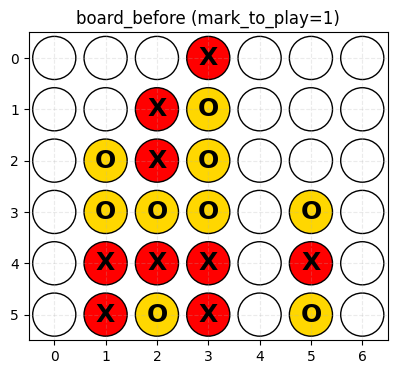

Legal cols: [0, 1, 2, 4, 5, 6]
Win cols for MARK_TO_PLAY: []
Win cols for opponent: []


In [4]:
MARK_TO_PLAY = 1

board_before = np.array([[0, 0, 0, 1, 0, 0, 0], [0, 0, 1, 2, 0, 0, 0], [0, 2, 1, 2, 0, 0, 0], [0, 2, 2, 2, 0, 2, 0], [0, 1, 1, 1, 0, 1, 0], [0, 1, 2, 1, 0, 2, 0]], dtype=np.int8)

assert board_before.shape == (6,7)
assert MARK_TO_PLAY in (1,2)

fig, ax = plt.subplots(figsize=(5,4))
draw_board(ax, board_before, title=f"board_before (mark_to_play={MARK_TO_PLAY})")
plt.show()

print("Legal cols:", legal_cols(board_before))
print("Win cols for MARK_TO_PLAY:", win_cols(board_before, MARK_TO_PLAY))
print("Win cols for opponent:", win_cols(board_before, opp_mark(MARK_TO_PLAY)))


In [5]:
def board_np_to_kaggle_list(board_np: np.ndarray) -> list:
    """Flatten 6x7 np board (top row first) to Kaggle list (len 42)."""
    # Kaggle ConnectX uses marks {0,1,2}. If you ever store {-1, +1},
    # convert before calling this (see kaggle_action below).
    return [int(board_np[r, c]) for r in range(6) for c in range(7)]

def kaggle_action(board_np: np.ndarray, mark: int) -> int:
    """
    board_np: 6x7, top row first, values in {0,1,2} (or {0,1,-1} will be converted).
    mark:     Kaggle mark: 1 or 2
    """
    b = np.asarray(board_np, dtype=np.int8)

    # If board uses {-1,+1} convention, convert to {2,1}.
    if np.any(b == -1):
        b = b.copy()
        b[b == -1] = 2

    obs = {"board": board_np_to_kaggle_list(b), "mark": int(mark)}
    config = {"rows": 6, "columns": 7, "inarow": 4, "timeout": 2.0}
    return int(N_step_lookahead_bitboard(obs, config))



In [6]:
def apply_move_with_row(board: np.ndarray, col: int, mark: int):
    """apply_move() + also return landing row (top-based)."""
    after = apply_move(board, col, mark)

    diff = np.argwhere(after != board)
    if diff.shape[0] != 1:
        raise ValueError(f"Expected exactly 1 changed cell, got {diff.shape[0]}")
    landing_r = int(diff[0, 0])  # top-based row index 0..5

    return after, landing_r


def eval_depths(board: np.ndarray, mark: int, depths, compute_action_scores: bool = True):
    la = Connect4Lookahead()

    rows = []
    for d in depths:
        d = int(d)

        # chosen move at this depth
        mv = int(la.n_step_lookahead(board, mark, depth=d))

        # apply_move_with_row returns (after_board, landing_row)
        after, landing_r = apply_move_with_row(board, mv, mark)

        opp = opp_mark(mark)

        win_now = bool(la.has_four(after, mark))
        opp_win1_cols = win_cols(after, opp)
        my_win1_cols  = win_cols(after, mark)

        # simple "tactical reward" (placeholder, like you said)
        reward = 1 if win_now else (-1 if len(opp_win1_cols) > 0 else 0)

        rec = {
            "depth": d,
            "la_col": mv,
            "landing_r": int(landing_r),
            "reward_tactical": int(reward),
            "win_now": bool(win_now),
            "my_imw_after": int(len(my_win1_cols)),
            "opp_imw_after": int(len(opp_win1_cols)),
        }

        # per-column score curve (optional)
        if compute_action_scores:
            sc = la.n_step_action_scores(board, mark, depth=d)  # shape (7,)
            rec["scores"] = np.asarray(sc, dtype=np.float64)
            rec["best_col_by_scores"] = int(np.nanargmax(rec["scores"]))

        rows.append(rec)

    df = pd.DataFrame(rows).sort_values("depth").reset_index(drop=True)
    return df



In [7]:
%%time
df_la = eval_depths(board_before, MARK_TO_PLAY, DEPTHS, compute_action_scores=COMPUTE_ACTION_SCORES)
display(df_la)

,depth,la_col,landing_r,reward_tactical,win_now,my_imw_after,opp_imw_after,scores,best_col_by_scores
0,1,4,5,0,False,1,0,"[157331.30625, 1187.24375, 1145.1046875, -inf,...",4
1,2,1,1,0,False,0,0,"[-156949.909375, 0.4187499999999822, -156459.0...",1
2,3,1,1,0,False,0,0,"[847.96875, 158134.15625, 1492.5734375, -inf, ...",1
3,4,1,1,0,False,0,0,"[-156752.01875, -1.9312500000000157, -156460.2...",1
4,5,1,1,0,False,0,0,"[812.78125, 158017.7265625, 1493.43125, -inf, ...",1
5,6,2,0,0,False,0,0,"[-156638.93125, -111.8515625, -3.6500000000000...",2
6,7,2,0,0,False,0,0,"[960.6171875, 157892.41875, 157901.31875, -inf...",2
7,8,5,2,0,False,0,0,"[-325.81875, -114.896875, -114.896875, -inf, -...",5
8,9,5,2,0,False,0,0,"[157631.64375, 157770.825, 157770.825, -inf, 1...",5
9,10,5,2,0,False,0,0,"[-285.73125, -91.98125, -91.98125, -inf, -1572...",5


CPU times: total: 6.64 s
Wall time: 6.86 s


In [8]:
print(tabulate(df_la["scores"]))

--  -----------  ------------  ------------  ----  -----------  ------------  -----------
 0   157331        1187.24        1145.1     -inf   158372         1184.22       1186.87
 1  -156950           0.41875  -156459       -inf  -158561      -156580       -156579
 2      847.969  158134           1492.57    -inf      575.5       1149.03       1151.68
 3  -156752          -1.93125  -156460       -inf  -157395          -46.8313  -156336
 4      812.781  158018           1493.43    -inf      179.188   158017          1533.91
 5  -156639        -111.852         -3.65    -inf  -157272         -111.852      -387.392
 6      960.617  157892         157901       -inf      509.391   157889        157756
 7     -325.819    -114.897       -114.897   -inf  -157457         -112.922      -389.5
 8   157632      157771         157771       -inf      183.334   157960        157765
 9     -285.731     -91.9813       -91.9813  -inf  -157263           11.6656     -343.812
10   157632      157649        

In [9]:
# --- Add Kaggle row ---
df_all = df_la.copy()

kmv = kaggle_action(board_before, MARK_TO_PLAY)

after_k, r_k = apply_move_with_row(board_before, int(kmv), MARK_TO_PLAY)

rec = dict(
    depth="KAGGLE",
    la_col=int(kmv),                 # keep same column name as df_la
    landing_r=int(r_k),
    reward_tactical=int(1 if la.has_four(after_k, MARK_TO_PLAY)
                        else (-1 if len(win_cols(after_k, opp_mark(MARK_TO_PLAY))) > 0 else 0)),
    win_now=bool(la.has_four(after_k, MARK_TO_PLAY)),
    my_imw_after=len(win_cols(after_k, MARK_TO_PLAY)),
    opp_imw_after=len(win_cols(after_k, opp_mark(MARK_TO_PLAY))),
)

rec["my_win_cols"]  = str(win_cols(after_k, MARK_TO_PLAY))
rec["opp_win_cols"] = str(win_cols(after_k, opp_mark(MARK_TO_PLAY)))


df_all = pd.concat([df_all, pd.DataFrame([rec])], ignore_index=True)

display(df_all)


DEBUG depth_end best_move 2 best_val 157900.81875
Depth reached 7 time remaining 1.7402695999480784 OVER False


,depth,la_col,landing_r,reward_tactical,win_now,my_imw_after,opp_imw_after,scores,best_col_by_scores,my_win_cols,opp_win_cols
0,1,4,5,0,False,1,0,"[157331.30625, 1187.24375, 1145.1046875, -inf,...",4.0,NaN,NaN
1,2,1,1,0,False,0,0,"[-156949.909375, 0.4187499999999822, -156459.0...",1.0,NaN,NaN
2,3,1,1,0,False,0,0,"[847.96875, 158134.15625, 1492.5734375, -inf, ...",1.0,NaN,NaN
3,4,1,1,0,False,0,0,"[-156752.01875, -1.9312500000000157, -156460.2...",1.0,NaN,NaN
4,5,1,1,0,False,0,0,"[812.78125, 158017.7265625, 1493.43125, -inf, ...",1.0,NaN,NaN
5,6,2,0,0,False,0,0,"[-156638.93125, -111.8515625, -3.6500000000000...",2.0,NaN,NaN
6,7,2,0,0,False,0,0,"[960.6171875, 157892.41875, 157901.31875, -inf...",2.0,NaN,NaN
7,8,5,2,0,False,0,0,"[-325.81875, -114.896875, -114.896875, -inf, -...",5.0,NaN,NaN
8,9,5,2,0,False,0,0,"[157631.64375, 157770.825, 157770.825, -inf, 1...",5.0,NaN,NaN
9,10,5,2,0,False,0,0,"[-285.73125, -91.98125, -91.98125, -inf, -1572...",5.0,NaN,NaN


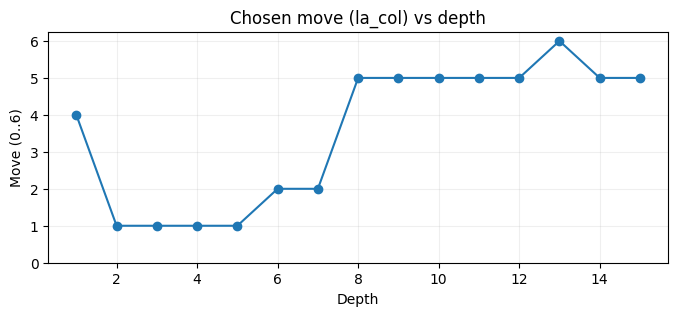

No child value column found. Available columns: ['depth', 'la_col', 'landing_r', 'reward_tactical', 'win_now', 'my_imw_after', 'opp_imw_after', 'scores', 'best_col_by_scores']


In [10]:
# --- Plot: chosen move & child_value vs depth ---

dfp = df_la.copy()

# pick the actual move column name that exists
MOVE_COL = "move" if "move" in dfp.columns else ("la_col" if "la_col" in dfp.columns else "col")
VAL_COL  = "child_value" if "child_value" in dfp.columns else ("child_search_value" if "child_search_value" in dfp.columns else None)

dfp["depth"] = dfp["depth"].astype(int)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(dfp["depth"], dfp[MOVE_COL], marker="o")
ax.set_title(f"Chosen move ({MOVE_COL}) vs depth")
ax.set_xlabel("Depth")
ax.set_ylabel("Move (0..6)")
ax.set_yticks(range(7))
ax.grid(True, alpha=0.2)
plt.show()

if VAL_COL is not None:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(dfp["depth"], dfp[VAL_COL], marker="o")
    ax.set_title(f"{VAL_COL}({MOVE_COL}) vs depth")
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.2)
    plt.show()
else:
    print("No child value column found. Available columns:", list(dfp.columns))


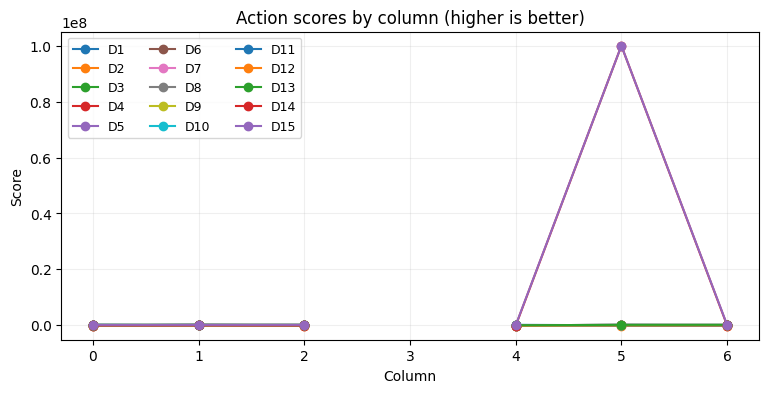

In [11]:
# --- Plot: per-column score curves (optional) ---
if COMPUTE_ACTION_SCORES and "scores" in df_la.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = list(range(7))

    for _, row in df_la.iterrows():
        d = int(row["depth"])
        ys = row["scores"]
        if ys is None:
            continue
        ax.plot(xs, ys, marker="o", label=f"D{d}")

    ax.set_title("Action scores by column (higher is better)")
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")
    ax.set_xticks(xs)
    ax.grid(True, alpha=0.2)
    ax.legend(ncols=3, fontsize=9)
    plt.show()
else:
    print("COMPUTE_ACTION_SCORES=False (or missing scores) -> skipping plot.")


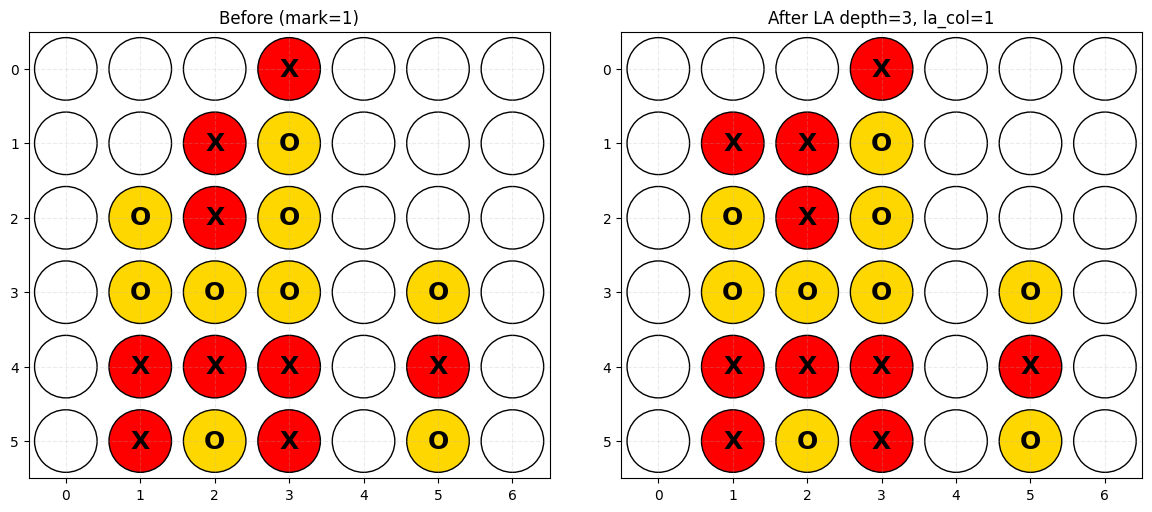

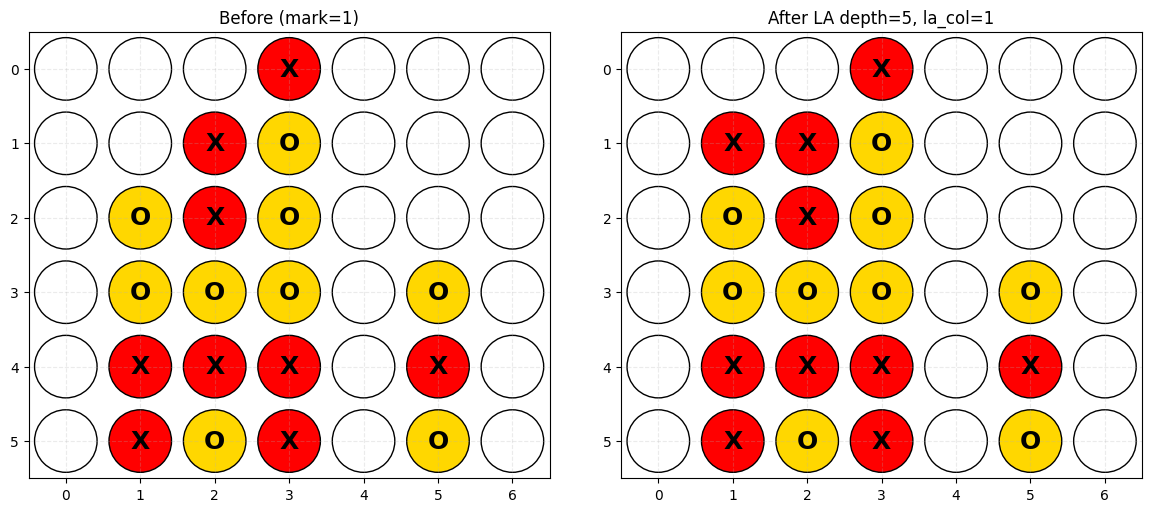

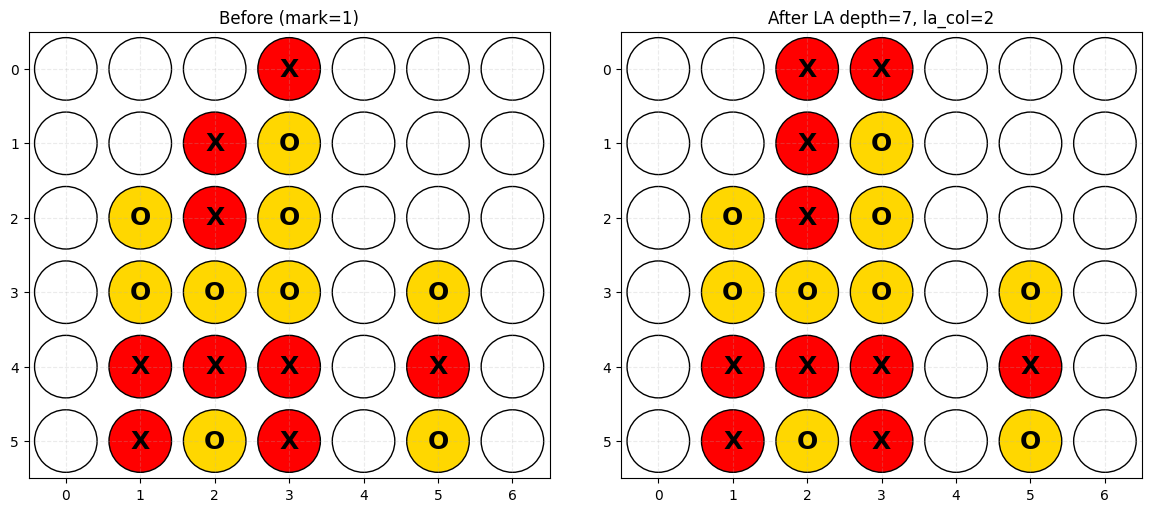

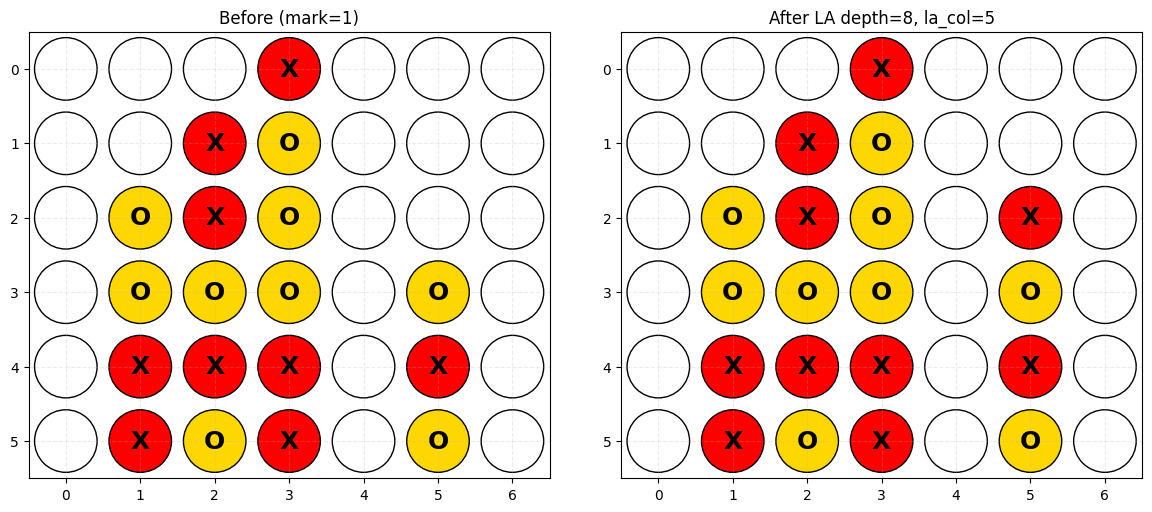

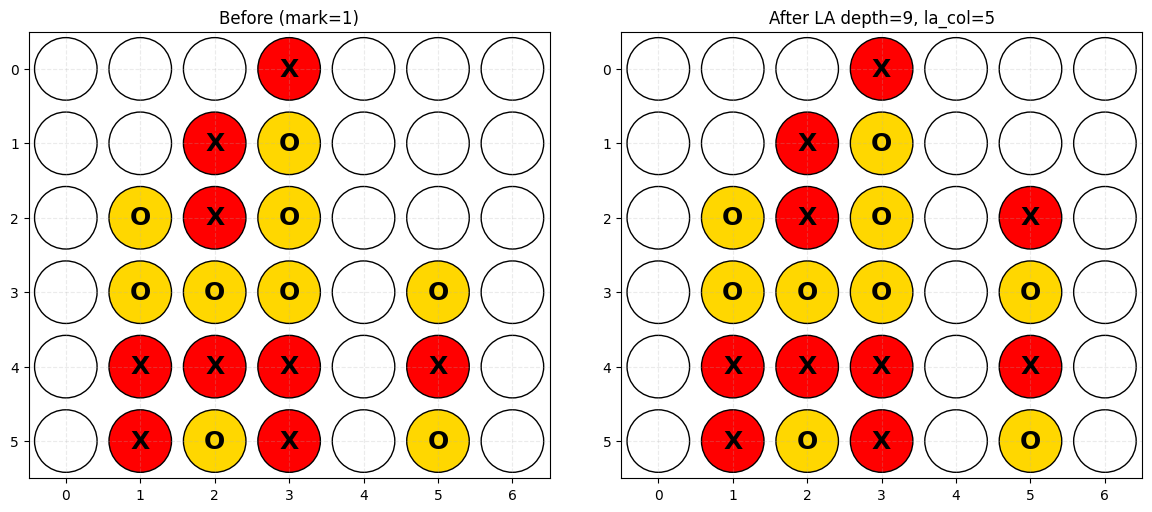

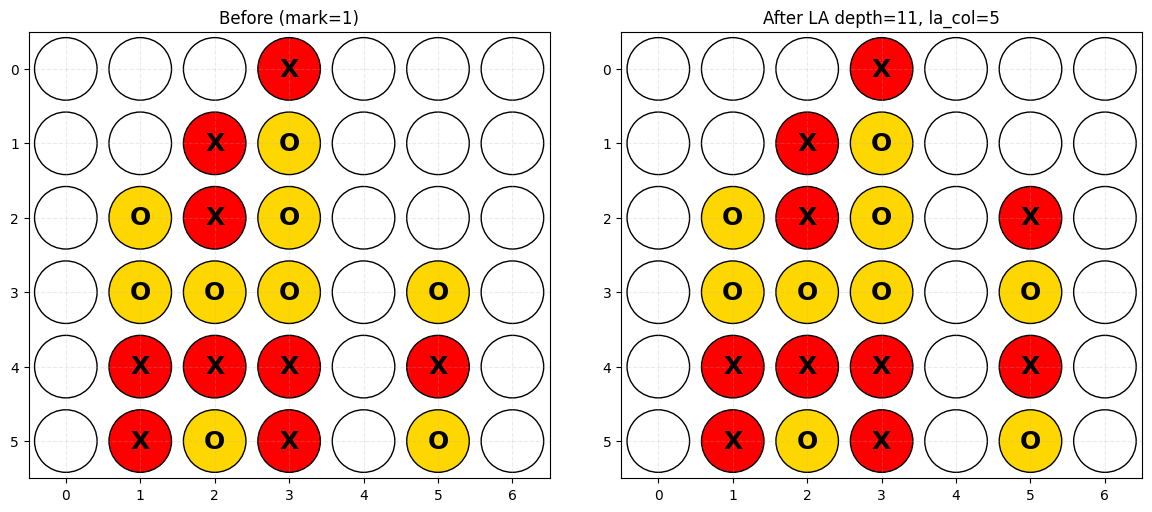

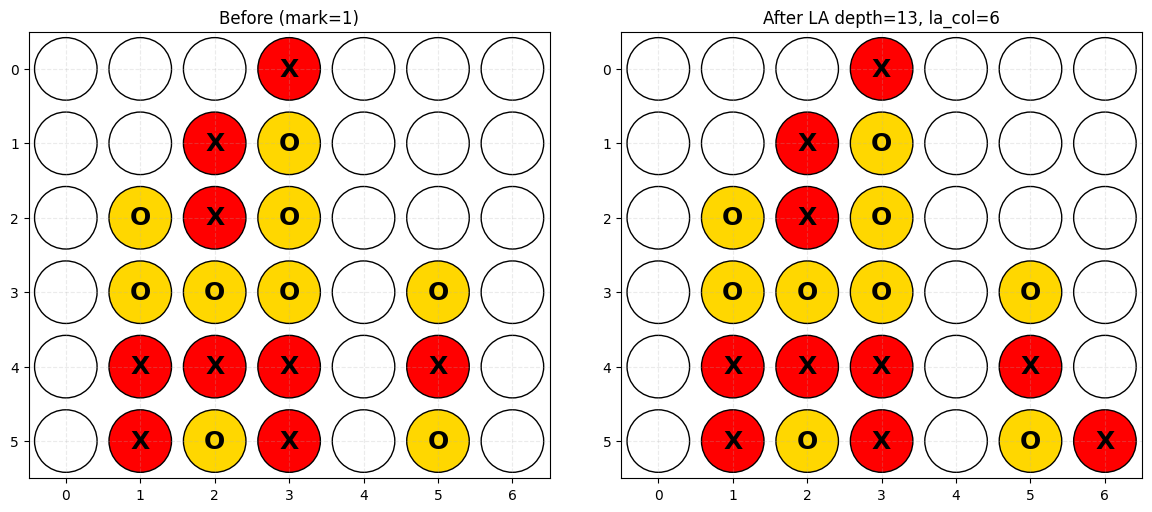

DEBUG depth_end best_move 2 best_val 157900.81875
Depth reached 7 time remaining 1.742111700004898 OVER False


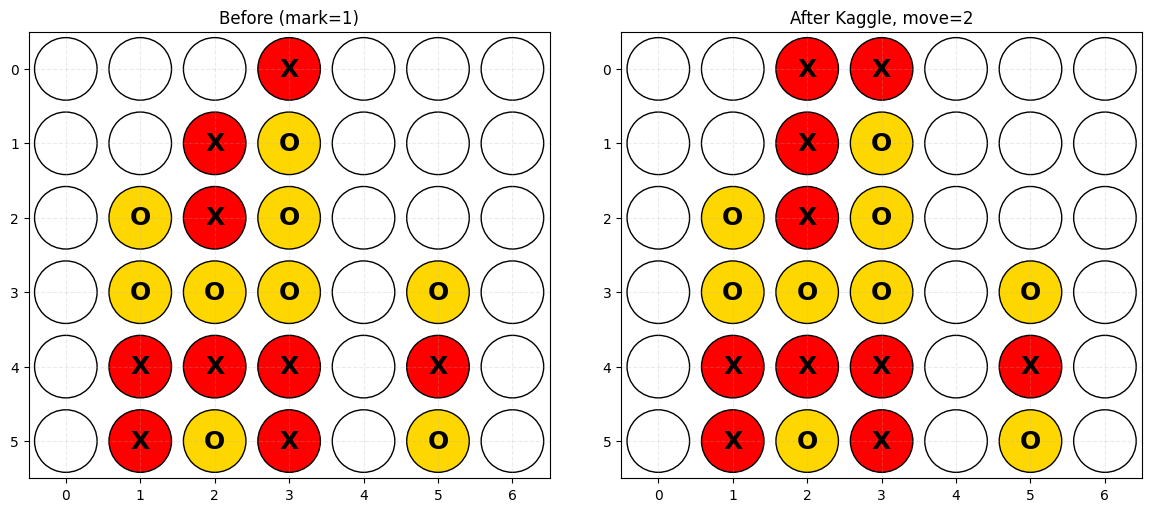

array([[0, 0, 1, 1, 0, 0, 0],
       [0, 0, 1, 2, 0, 0, 0],
       [0, 2, 1, 2, 0, 0, 0],
       [0, 2, 2, 2, 0, 2, 0],
       [0, 1, 1, 1, 0, 1, 0],
       [0, 1, 2, 1, 0, 2, 0]], dtype=int8)

In [12]:
# --- Board visuals: before/after for selected depths + Kaggle ---

def show_after_for_move(board, mark, mv, title_after):
    after = apply_move(board, int(mv), int(mark))
    show_two_boards(
        board, f"Before (mark={mark})",
        after, title_after,
        suptitle=""
    )
    return after

# Show LA depth picks
for d in SHOW_BOARDS_FOR:
    mv = int(df_la.loc[df_la["depth"] == int(d), "la_col"].iloc[0])
    show_after_for_move(
        board_before, MARK_TO_PLAY, mv,
        title_after=f"After LA depth={d}, la_col={mv}"
    )

# Show Kaggle pick
kmv = kaggle_action(board_before, MARK_TO_PLAY)
show_after_for_move(
    board_before, MARK_TO_PLAY, int(kmv),
    title_after=f"After Kaggle, move={int(kmv)}"
)


In [15]:
# --- Quick "knob flip" helper ---
# Use this to test whether a knob meaningfully changes the chosen move on THIS board.

def set_knobs(**kwargs):
    for k, v in kwargs.items():
        if not hasattr(la, k):
            raise AttributeError(f"LA has no attribute {k}")
        setattr(la, k, v)

def quick_recheck(depth=7):
    mv = int(la.n_step_lookahead(board_before, MARK_TO_PLAY, depth=int(depth)))
    after = apply_move(board_before, mv, MARK_TO_PLAY)

    win_now = bool(la.has_four(after, MARK_TO_PLAY))
    opp_imw = list(la.count_immediate_wins(after, opp_mark(MARK_TO_PLAY)))

    print(f"Depth {int(depth)} -> la_col={mv} | win_now={win_now} | opp_imw_after={opp_imw}")
    return mv

# Example:
#set_knobs(PARITY_BONUS=1.0)   
#set_knobs(FLOATING_NEAR=0.25)
#set_knobs(FLOATING_FAR=0.075)
#set_knobs(FLOATING_NEAR=0.5)
#set_knobs(FLOATING_FAR=0.35)
#set_knobs(DEFENSIVE=1.3)
#set_knobs(CENTER_BONUS=7)
#set_knobs(CENTER_BONUS=7)
#set_knobs(VERT_MUL=0.7)
#set_knobs(TEMPO_W=0.50)
#set_knobs(PARITY_MOVE_W=0.30)
#set_knobs(PARITY_UNLOCK_W=0.20)
#set_knobs(THREATSPACE_W=0.55)


quick_recheck(7) #goal is 5 (not 2)


Depth 7 -> la_col=2 | win_now=False | opp_imw_after=[]


2